# This noteboook contains out of sample analysis from LSTM model

In [9]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

In [28]:
def rename_cols(df, tag):
    return df.rename(columns={
        "actual": f"actual_{tag}",
        "predicted": f"predicted_{tag}"
    })

# motivation for our project: degradation of performance when training data is reduced
normal = pd.read_csv("results/lstm_test_results.csv")
r25 = pd.read_csv("results/lstm_reduce25_results.csv")
r50 = pd.read_csv("results/lstm_reduce50_results.csv")
r75 = pd.read_csv("results/lstm_reduce75_results.csv")

# rename columns
normal_ = rename_cols(normal, "normal")
r25_    = rename_cols(r25, "r25")
r50_    = rename_cols(r50, "r50")
r75_    = rename_cols(r75, "r75")

# merge on test_index
df_mo = (
    normal_
    .merge(r25_[["test_index", "predicted_r25", "Date"]], on="test_index", how="left")
    .merge(r50_[["test_index", "predicted_r50"]], on="test_index", how="left")
    .merge(r75_[["test_index", "predicted_r75"]], on="test_index", how="left")
)

# clean up columns
df_mo = df_mo.rename(columns={
    "Date": "date",
    "actual_normal": "actual"
})

df_mo = df_mo[[
    "test_index",
    "date",
    "actual",
    "predicted_normal",
    "predicted_r25",
    "predicted_r50",
    "predicted_r75"
]]

df_mo['date'] = pd.to_datetime(df_mo['date'])

df_mo

,test_index,date,actual,predicted_normal,predicted_r25,predicted_r50,predicted_r75
0,408,2020-02-01,-0.129368,-0.134410,-0.070244,0.029101,0.010852
1,409,2020-03-01,-0.548254,-0.391728,-0.356105,-0.539941,-0.352636
2,410,2020-04-01,-0.568125,-4.403046,-2.154252,-1.818807,-2.169874
3,411,2020-05-01,0.545621,-2.237060,-2.421526,-2.016214,-1.860990
4,412,2020-06-01,0.293704,-0.655051,0.978611,0.427409,0.917468
...,...,...,...,...,...,...,...
67,475,2025-09-01,-0.013973,-0.176021,-0.276074,-0.296182,-0.189831
68,476,2025-10-01,-0.049189,0.016525,-0.132746,-0.121128,-0.108308
69,477,2025-11-01,-0.013725,-0.115676,-0.296283,-0.261128,-0.250057
70,478,2025-12-01,-0.035418,-0.008562,-0.138526,-0.113275,-0.288786


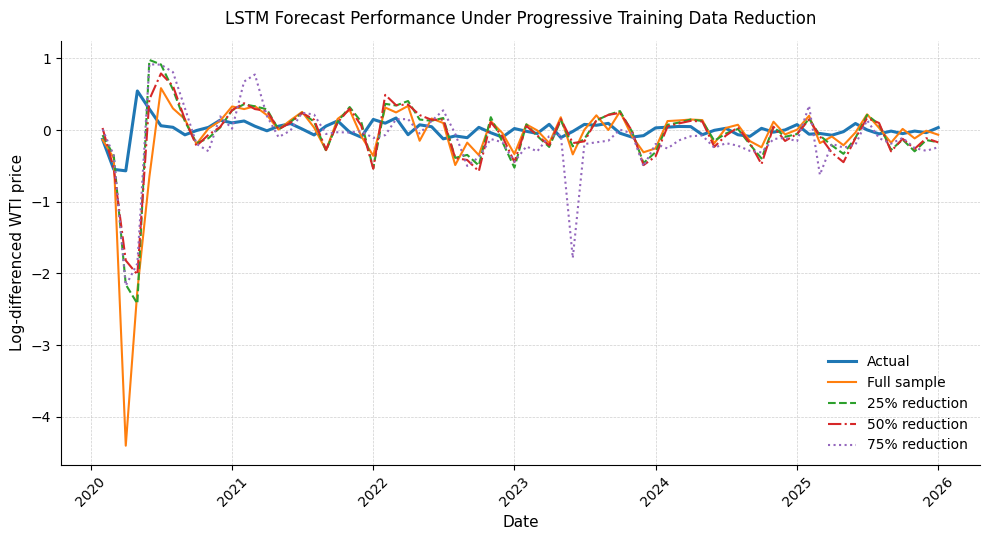

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# make sure date is datetime
df_mo["date"] = pd.to_datetime(df_mo["date"])

# sort by date just in case
df_mo = df_mo.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5))

# actual series: thicker and darker
ax.plot(
    df_mo["date"],
    df_mo["actual"],
    label="Actual",
    linewidth=2.2
)

# predicted series
ax.plot(
    df_mo["date"],
    df_mo["predicted_normal"],
    label="Full sample",
    linewidth=1.5,
    linestyle="-"
)

ax.plot(
    df_mo["date"],
    df_mo["predicted_r25"],
    label="25% reduction",
    linewidth=1.5,
    linestyle="--"
)

ax.plot(
    df_mo["date"],
    df_mo["predicted_r50"],
    label="50% reduction",
    linewidth=1.5,
    linestyle="-."
)

ax.plot(
    df_mo["date"],
    df_mo["predicted_r75"],
    label="75% reduction",
    linewidth=1.5,
    linestyle=":"
)

# labels
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Log-differenced WTI price", fontsize=11)
ax.set_title("LSTM Forecast Performance Under Progressive Training Data Reduction", fontsize=12, pad=12)

# clean academic formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

# date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="best"
)

plt.tight_layout()
# plt.savefig("results/motivation_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
import pandas as pd

def rename_pred_only(df, tag):
    return df.rename(columns={"predicted": f"predicted_{tag}"})

normal = pd.read_csv("results/lstm_test_results.csv")
jitter1 = pd.read_csv("results/lstm_test_jitter_results.csv")
timegan1 = pd.read_csv("results/lstm_test_timegan_results.csv")
vaetimegan1 = pd.read_csv("results/lstm_test_vaetimegan_results.csv")

jitter1_ = rename_pred_only(jitter1, "jitter")
timegan1_ = rename_pred_only(timegan1, "timegan")
vaetimegan1_ = rename_pred_only(vaetimegan1, "vaetimegan")

# step 1: merge normal with jitter on test_index
df1 = normal.merge(
    jitter1_[["test_index", "predicted_jitter", "Date"]],
    on="test_index",
    how="left"
)

# step 2: convert Date to datetime
df1["Date"] = pd.to_datetime(df1["Date"])
timegan1_["Date"] = pd.to_datetime(timegan1_["Date"])
vaetimegan1_["Date"] = pd.to_datetime(vaetimegan1_["Date"])

# step 3: merge on Date
df1 = (
    df1
    .merge(timegan1_[["Date", "predicted_timegan"]], on="Date", how="left")
    .merge(vaetimegan1_[["Date", "predicted_vaetimegan"]], on="Date", how="left")
)

# step 4: clean names
df1 = df1.rename(columns={
    "predicted": "predicted_normal",
    "Date": "date"
})

df1 = df1[[
    "test_index",
    "date",
    "actual",
    "predicted_normal",
    "predicted_jitter",
    "predicted_timegan",
    "predicted_vaetimegan"
]]

df1 = df1.rename(columns={
    "predicted_normal": "normal",
    "predicted_jitter": "jitter",
    "predicted_timegan": "timegan",
    "predicted_vaetimegan": "vaetimegan"
})

print(df1)

    test_index       date    actual    normal    jitter   timegan  vaetimegan
0          408 2020-02-01 -0.129368 -0.134410 -0.095768 -0.107499   -0.123832
1          409 2020-03-01 -0.548254 -0.391728 -0.384119 -0.238859   -0.428196
2          410 2020-04-01 -0.568125 -4.403046 -4.757118 -3.902027   -3.551772
3          411 2020-05-01  0.545621 -2.237060 -1.931571 -2.552425   -3.653004
4          412 2020-06-01  0.293704 -0.655051 -0.446201  0.040100   -0.358767
..         ...        ...       ...       ...       ...       ...         ...
67         475 2025-09-01 -0.013973 -0.176021 -0.140391 -0.087172   -0.181329
68         476 2025-10-01 -0.049189  0.016525  0.021400  0.069552   -0.010663
69         477 2025-11-01 -0.013725 -0.115676 -0.108951 -0.091096   -0.097741
70         478 2025-12-01 -0.035418 -0.008562  0.017039  0.000172   -0.018151
71         479 2026-01-01  0.035085 -0.064826 -0.094009 -0.025984   -0.075062

[72 rows x 7 columns]


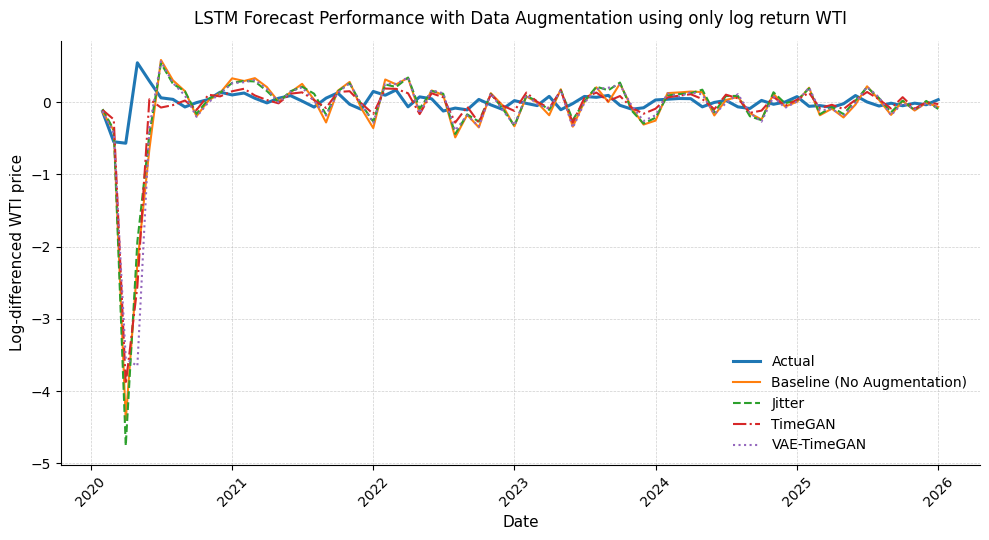

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ensure datetime + sorted
df1["date"] = pd.to_datetime(df1["date"])
df1 = df1.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5))

# actual (anchor line)
ax.plot(
    df1["date"],
    df1["actual"],
    label="Actual",
    linewidth=2.2
)

# baseline
ax.plot(
    df1["date"],
    df1["normal"],
    label="Baseline (No Augmentation)",
    linewidth=1.5,
    linestyle="-"
)

# augmentation methods
ax.plot(
    df1["date"],
    df1["jitter"],
    label="Jitter",
    linewidth=1.5,
    linestyle="--"
)

ax.plot(
    df1["date"],
    df1["timegan"],
    label="TimeGAN",
    linewidth=1.5,
    linestyle="-."
)

ax.plot(
    df1["date"],
    df1["vaetimegan"],
    label="VAE-TimeGAN",
    linewidth=1.5,
    linestyle=":"
)

# labels
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Log-differenced WTI price", fontsize=11)
ax.set_title(
    "LSTM Forecast Performance with Data Augmentation using only log return WTI",
    fontsize=12,
    pad=12
)

# clean academic styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

# date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# legend
ax.legend(frameon=False, fontsize=10, loc="best")

plt.tight_layout()
# plt.savefig("results/augmentation_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
import pandas as pd

def rename_pred_only(df, tag):
    return df.rename(columns={"predicted": f"predicted_{tag}"})

normal2 = pd.read_csv("results/lstm-1_results.csv")
jitter2 = pd.read_csv("results/lstm-1-jitter_results.csv")
timegan2 = pd.read_csv("results/lstm-1-timegan_results.csv")
vaetimegan2 = pd.read_csv("results/lstm-1-vaetimegan_results.csv")

# rename prediction columns
normal2 = normal2.rename(columns={"predicted": "predicted_normal"})
jitter2_ = rename_pred_only(jitter2, "jitter")
timegan2_ = rename_pred_only(timegan2, "timegan")
vaetimegan2_ = rename_pred_only(vaetimegan2, "vaetimegan")

# ensure datetime consistency
for df in [normal2, jitter2_, timegan2_, vaetimegan2_]:
    df["Date"] = pd.to_datetime(df["Date"])

# merge everything on Date
df2 = (
    normal2
    .merge(jitter2_[["Date", "predicted_jitter"]], on="Date", how="left")
    .merge(timegan2_[["Date", "predicted_timegan"]], on="Date", how="left")
    .merge(vaetimegan2_[["Date", "predicted_vaetimegan"]], on="Date", how="left")
)

# clean final structure
df2 = df2.rename(columns={"Date": "date"})

df2 = df2[[
    "test_index",   # optional (can drop later)
    "date",
    "actual",
    "predicted_normal",
    "predicted_jitter",
    "predicted_timegan",
    "predicted_vaetimegan"
]]

# nicer naming for plotting
df2 = df2.rename(columns={
    "predicted_normal": "normal",
    "predicted_jitter": "jitter",
    "predicted_timegan": "timegan",
    "predicted_vaetimegan": "vaetimegan"
})

print(df2.head())

   test_index       date    actual    normal    jitter   timegan  vaetimegan
0         408 2020-02-01 -0.129368 -0.105016 -0.104418 -0.155670   -0.191981
1         409 2020-03-01 -0.548254 -0.318849 -0.345342 -0.275730   -0.361700
2         410 2020-04-01 -0.568125 -2.936830 -2.932549 -2.159197   -4.492795
3         411 2020-05-01  0.545621 -1.755277 -2.101354 -2.861788   -2.929322
4         412 2020-06-01  0.293704  0.897916  1.077502  0.539141    0.034143


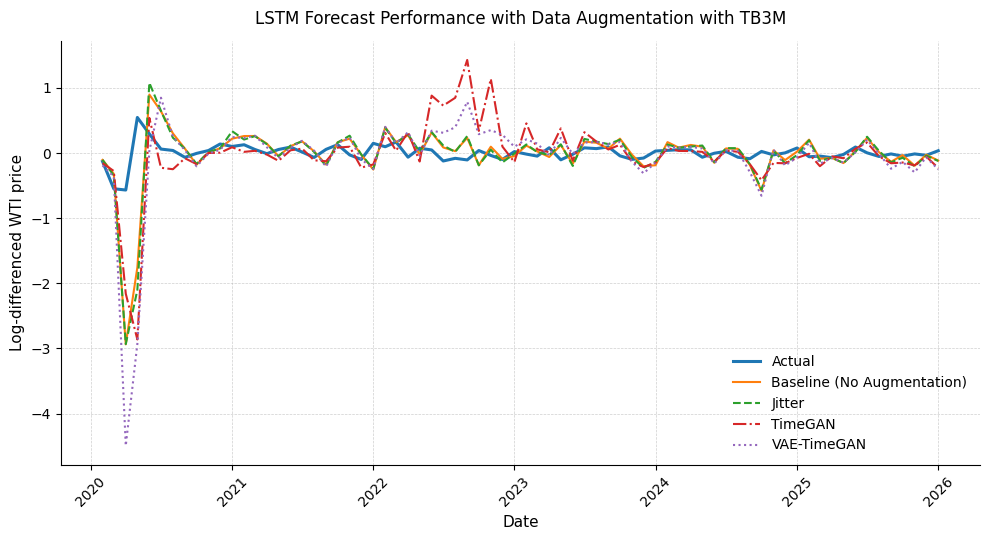

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# make sure date is datetime
df2["date"] = pd.to_datetime(df2["date"])
df2 = df2.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5))

# actual
ax.plot(
    df2["date"],
    df2["actual"],
    label="Actual",
    linewidth=2.2
)

# forecasts
ax.plot(
    df2["date"],
    df2["normal"],
    label="Baseline (No Augmentation)",
    linewidth=1.5,
    linestyle="-"
)

ax.plot(
    df2["date"],
    df2["jitter"],
    label="Jitter",
    linewidth=1.5,
    linestyle="--"
)

ax.plot(
    df2["date"],
    df2["timegan"],
    label="TimeGAN",
    linewidth=1.5,
    linestyle="-."
)

ax.plot(
    df2["date"],
    df2["vaetimegan"],
    label="VAE-TimeGAN",
    linewidth=1.5,
    linestyle=":"
)

# labels
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Log-differenced WTI price", fontsize=11)
ax.set_title("LSTM Forecast Performance with Data Augmentation with TB3M", fontsize=12, pad=12)

# clean academic style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

# date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# legend
ax.legend(frameon=False, fontsize=10, loc="best")

plt.tight_layout()
# plt.savefig("results/lstm_1_augmentation_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
import pandas as pd

def rename_pred_only(df, tag):
    return df.rename(columns={"predicted": f"predicted_{tag}"})

normal3 = pd.read_csv("results/lstm-8_results.csv")
jitter3 = pd.read_csv("results/lstm-8-jitter_results.csv")
timegan3 = pd.read_csv("results/lstm-8-timegan_results.csv")
vaetimegan3 = pd.read_csv("results/lstm-8-vaetimegan_results.csv")

# rename prediction columns
normal3 = normal3.rename(columns={"predicted": "predicted_normal"})
jitter3_ = rename_pred_only(jitter3, "jitter")
timegan3_ = rename_pred_only(timegan3, "timegan")
vaetimegan3_ = rename_pred_only(vaetimegan3, "vaetimegan")

# ensure datetime consistency
for df in [normal3, jitter3_, timegan3_, vaetimegan3_]:
    df["Date"] = pd.to_datetime(df["Date"])

# merge everything on Date
df3 = (
    normal3
    .merge(jitter3_[["Date", "predicted_jitter"]], on="Date", how="left")
    .merge(timegan3_[["Date", "predicted_timegan"]], on="Date", how="left")
    .merge(vaetimegan3_[["Date", "predicted_vaetimegan"]], on="Date", how="left")
)

# clean final structure
df3 = df3.rename(columns={"Date": "date"})

df3 = df3[[
    "test_index",   # optional (can drop later)
    "date",
    "actual",
    "predicted_normal",
    "predicted_jitter",
    "predicted_timegan",
    "predicted_vaetimegan"
]]

# nicer naming for plotting
df3 = df3.rename(columns={
    "predicted_normal": "normal",
    "predicted_jitter": "jitter",
    "predicted_timegan": "timegan",
    "predicted_vaetimegan": "vaetimegan"
})

print(df3.head())

   test_index       date    actual    normal    jitter   timegan  vaetimegan
0         408 2020-02-01 -0.129368  0.021796 -0.105700 -0.030580   -0.264309
1         409 2020-03-01 -0.548254 -0.562555  0.488423 -0.912894   -0.448555
2         410 2020-04-01 -0.568125 -1.147854 -3.201234 -1.668196   -3.489446
3         411 2020-05-01  0.545621  0.604506 -1.672553 -4.626607   -1.181395
4         412 2020-06-01  0.293704  2.252935  0.584027  2.105507    0.916706


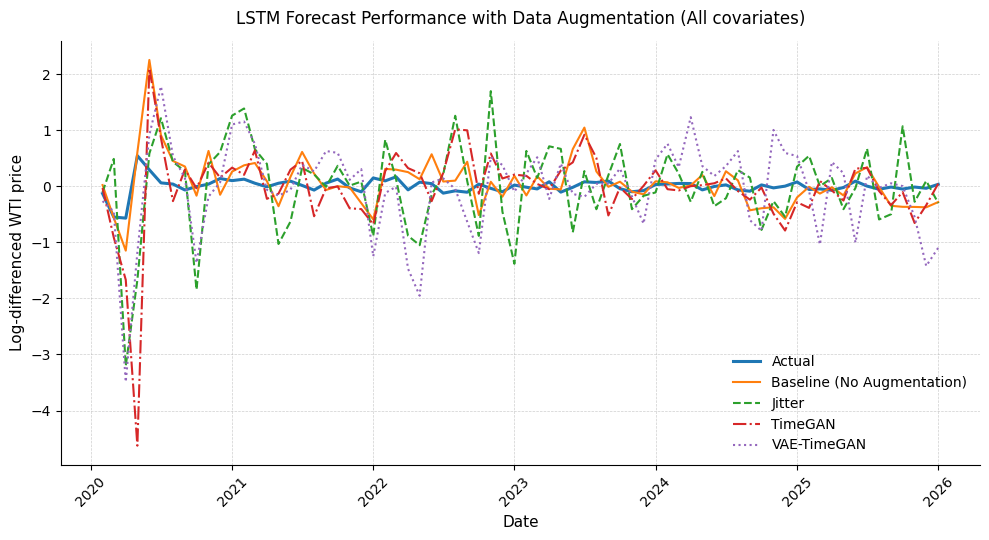

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ensure datetime and sort
df3["date"] = pd.to_datetime(df3["date"])
df3 = df3.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5))

# actual (anchor)
ax.plot(
    df3["date"],
    df3["actual"],
    label="Actual",
    linewidth=2.2
)

# baseline
ax.plot(
    df3["date"],
    df3["normal"],
    label="Baseline (No Augmentation)",
    linewidth=1.5,
    linestyle="-"
)

# augmentation methods
ax.plot(
    df3["date"],
    df3["jitter"],
    label="Jitter",
    linewidth=1.5,
    linestyle="--"
)

ax.plot(
    df3["date"],
    df3["timegan"],
    label="TimeGAN",
    linewidth=1.5,
    linestyle="-."
)

ax.plot(
    df3["date"],
    df3["vaetimegan"],
    label="VAE-TimeGAN",
    linewidth=1.5,
    linestyle=":"
)

# labels
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Log-differenced WTI price", fontsize=11)
ax.set_title("LSTM Forecast Performance with Data Augmentation (All covariates)", fontsize=12, pad=12)

# clean academic styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

# format dates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# legend
ax.legend(frameon=False, fontsize=10, loc="best")

plt.tight_layout()
# plt.savefig("results/lstm_8_augmentation_plot.png", dpi=300, bbox_inches="tight")
plt.show()